# 05. Health Metrics & HEAT Assessment

Exploratory analysis of health data for the Nørrebro healthy transport project. This notebook connects national mortality patterns, Copenhagen health survey data, and WHO HEAT economic assessment results to build a narrative around preventive care through active transport infrastructure.

**Data Sources:**
- `data/processed/health_survey_by_age.csv` — Danskernes Sundhed survey (7 indicators, Capital Region, 2023)
- `data/processed/health_survey_by_municipality.csv` — Danskernes Sundhed survey (6 indicators, per municipality, 2021)
- `data/processed/health_causes_of_death.csv` — StatBank DODA1 (national causes of death, 2007–2022)
- `data/processed/health_deaths_by_municipality.csv` — StatBank FOD207 (deaths by area, 2006–2025)
- `data/processed/heat_inputs.json` — WHO HEAT input parameters
- `data/processed/norrebro_neighbourhoods_population.csv` — Nørrebro demographics
- `data/raw/health/who_heat/*_results.csv` — WHO HEAT web tool results

**Goals:**
- Visualise Nørrebro population profile with HEAT-relevant age ranges
- Show national mortality context (leading causes of death)
- Compare Copenhagen health behaviours across age, gender, and municipality
- Present WHO HEAT economic assessment results
- Synthesise findings into a preventive care narrative

In [39]:
import json
import sys
from pathlib import Path

# Add project root to sys.path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

from src.visualization import style

style.apply_style()

## 1. Load Data

In [40]:
data_dir = project_root / "data" / "processed"
health_raw_dir = project_root / "data" / "raw" / "health"

# Processed health data
df_by_age = pd.read_csv(data_dir / "health_survey_by_age.csv")
df_by_muni = pd.read_csv(data_dir / "health_survey_by_municipality.csv")
df_doda1 = pd.read_csv(data_dir / "health_causes_of_death.csv")
df_fod207 = pd.read_csv(data_dir / "health_deaths_by_municipality.csv")

# HEAT inputs
with open(data_dir / "heat_inputs.json") as f:
    heat_inputs = json.load(f)

# Population
df_pop = pd.read_csv(data_dir / "norrebro_neighbourhoods_population.csv")

# WHO HEAT results
heat_results_files = sorted((health_raw_dir / "who_heat").glob("*_results.csv"))
if heat_results_files:
    df_heat_results = pd.read_csv(heat_results_files[0])
else:
    df_heat_results = pd.DataFrame()

print(
    f"Survey by age: {len(df_by_age)} rows, {df_by_age['indicator'].nunique()} indicators"
)
print(
    f"Survey by municipality: {len(df_by_muni)} rows, {df_by_muni['indicator'].nunique()} indicators"
)
print(f"DODA1 causes of death: {len(df_doda1)} rows")
print(f"FOD207 deaths by area: {len(df_fod207)} rows")
print(f"HEAT results: {len(df_heat_results)} rows")
print(f"Nørrebro population: {len(df_pop)} rows")

Survey by age: 126 rows, 7 indicators
Survey by municipality: 174 rows, 6 indicators
DODA1 causes of death: 25920 rows
FOD207 deaths by area: 12120 rows
HEAT results: 40 rows
Nørrebro population: 100 rows


## 2. Nørrebro Population Profile

In [41]:
# Aggregate population by age group across all neighbourhoods
pop_by_age = df_pop.groupby("ages")["people"].sum().reset_index()


# Parse age groups for sorting
def age_sort_key(age_str):
    """Extract lower bound for sorting."""
    age_str = age_str.strip()
    if "+" in age_str:
        return int(age_str.split("+")[0])
    parts = age_str.replace(" years", "").split("-")
    return int(parts[0])


pop_by_age["sort_key"] = pop_by_age["ages"].apply(age_sort_key)
pop_by_age = pop_by_age.sort_values("sort_key")

# HEAT age ranges
total_pop = pop_by_age["people"].sum()
walking_pop = heat_inputs["population"]["aged_20_74_walking"]
cycling_pop = heat_inputs["population"]["aged_20_64_cycling"]

print(f"Total Nørrebro population: {total_pop:,}")
print(f"Walking-eligible (20-74): {walking_pop:,} ({walking_pop / total_pop:.0%})")
print(f"Cycling-eligible (20-64): {cycling_pop:,} ({cycling_pop / total_pop:.0%})")

Total Nørrebro population: 79,753
Walking-eligible (20-74): 63,529 (80%)
Cycling-eligible (20-64): 59,605 (75%)


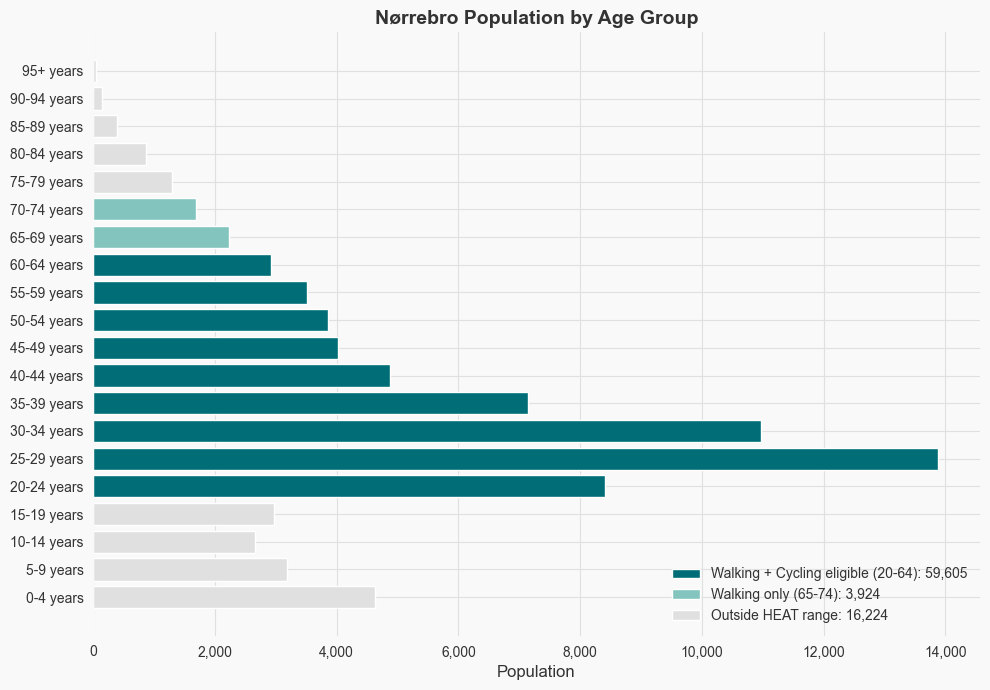

In [42]:
fig, ax = plt.subplots(figsize=(10, 7))

# Determine which bars fall in HEAT age ranges
colors = []
for _, row in pop_by_age.iterrows():
    lower = row["sort_key"]
    if 20 <= lower <= 64:
        colors.append(style.PALETTE["brand"])  # Both walking + cycling
    elif 65 <= lower <= 74:
        colors.append(style.PALETTE["brand_light"])  # Walking only
    else:
        colors.append(style.PALETTE["grid"])  # Outside HEAT ranges

ax.barh(pop_by_age["ages"], pop_by_age["people"], color=colors)
ax.set_xlabel("Population")
ax.set_title("Nørrebro Population by Age Group")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(
        facecolor=style.PALETTE["brand"],
        label=f"Walking + Cycling eligible (20-64): {cycling_pop:,}",
    ),
    Patch(
        facecolor=style.PALETTE["brand_light"],
        label=f"Walking only (65-74): {walking_pop - cycling_pop:,}",
    ),
    Patch(
        facecolor=style.PALETTE["grid"],
        label=f"Outside HEAT range: {total_pop - walking_pop:,}",
    ),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

## 3. National Mortality Context (DODA1)

Leading causes of death in Denmark. Heart disease, metabolic/diabetes, and respiratory diseases are directly linked to physical inactivity and can be addressed through active transport infrastructure.

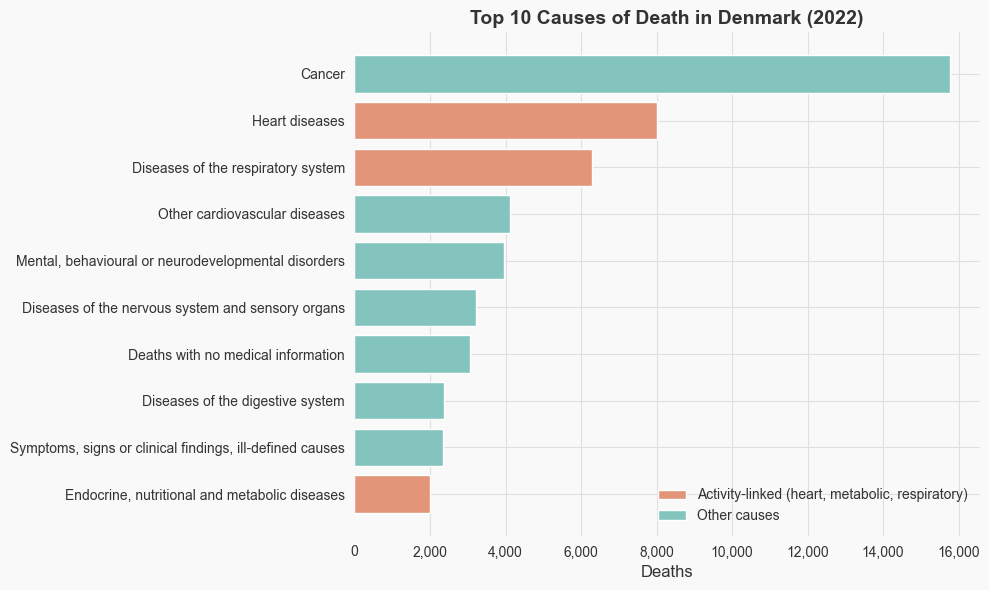


Activity-linked causes account for:
  16,319 of 59,121 deaths (28%)


In [43]:
# Most recent year, all ages, total gender
latest_year = df_doda1["year"].max()
mask = (
    (df_doda1["year"] == latest_year)
    & (df_doda1["age"] == "Age, total")
    & (df_doda1["gender"] == "Total")
    & (~df_doda1["cause"].isin(["TOTAL", "Cause of death unknown"]))
)
df_causes = df_doda1[mask].copy()
df_causes = df_causes.sort_values("deaths", ascending=True)

# Top 10 causes
df_top10 = df_causes.tail(10)

# Highlight activity-linked causes (heart disease, metabolic/diabetes, respiratory)
activity_linked = [
    "A-08 Heart diseases",
    "A-05 Endocrine, nutritional and metabolic diseases",
    "A-10 Diseases of the respiratory system",
]
colors = [
    style.PALETTE["accent_warm"]
    if c in activity_linked
    else style.PALETTE["brand_light"]
    for c in df_top10["cause"]
]

fig, ax = plt.subplots(figsize=(10, 6))
# Use short labels for readability
short_labels = [c.split(" ", 1)[1] if " " in c else c for c in df_top10["cause"]]
ax.barh(short_labels, df_top10["deaths"], color=colors)
ax.set_xlabel("Deaths")
ax.set_title(f"Top 10 Causes of Death in Denmark ({latest_year})")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

legend_elements = [
    Patch(
        facecolor=style.PALETTE["accent_warm"],
        label="Activity-linked (heart, metabolic, respiratory)",
    ),
    Patch(facecolor=style.PALETTE["brand_light"], label="Other causes"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

print(f"\nActivity-linked causes account for:")
activity_deaths = df_causes[df_causes["cause"].isin(activity_linked)]["deaths"].sum()
total_deaths = df_causes["deaths"].sum()
print(
    f"  {activity_deaths:,} of {total_deaths:,} deaths ({activity_deaths / total_deaths:.0%})"
)

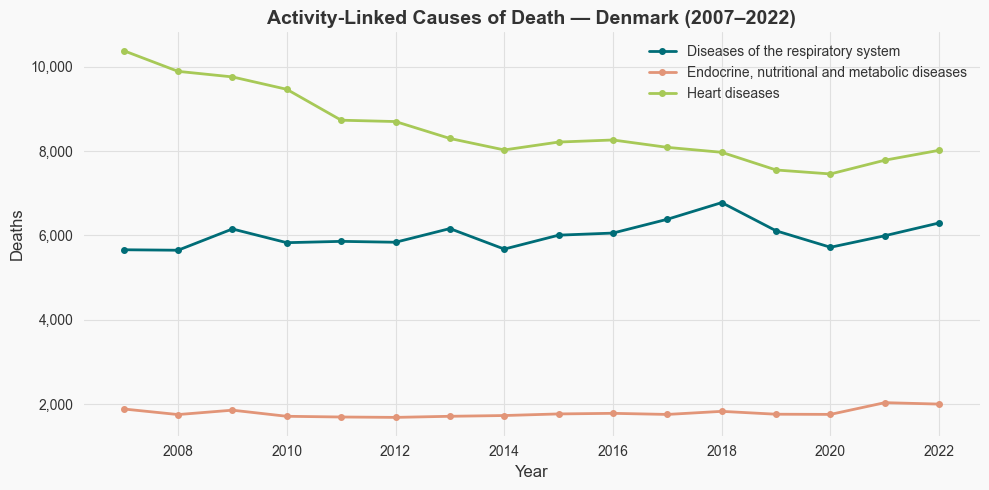

In [44]:
# Time trend for activity-linked causes
activity_linked = [
    "A-08 Heart diseases",
    "A-05 Endocrine, nutritional and metabolic diseases",
    "A-10 Diseases of the respiratory system",
]
mask_trend = (
    (df_doda1["cause"].isin(activity_linked))
    & (df_doda1["age"] == "Age, total")
    & (df_doda1["gender"] == "Total")
)
df_trend = df_doda1[mask_trend].copy()

# Short labels for the legend
df_trend["cause_label"] = df_trend["cause"].apply(
    lambda c: c.split(" ", 1)[1] if " " in c else c
)

fig, ax = plt.subplots(figsize=(10, 5))
for cause, group in df_trend.groupby("cause_label"):
    group = group.sort_values("year")
    ax.plot(group["year"], group["deaths"], marker="o", markersize=4, label=cause)

ax.set_xlabel("Year")
ax.set_ylabel("Deaths")
ax.set_title("Activity-Linked Causes of Death — Denmark (2007–2022)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.show()

## 4. Copenhagen vs National Mortality (FOD207)

Copenhagen has a calculated mortality rate of 278.7 per 100,000 (ages 20-74, 2023), substantially below the HEAT default for Denmark (500 per 100,000). This reflects Copenhagen's younger demographic profile and urban health advantages.

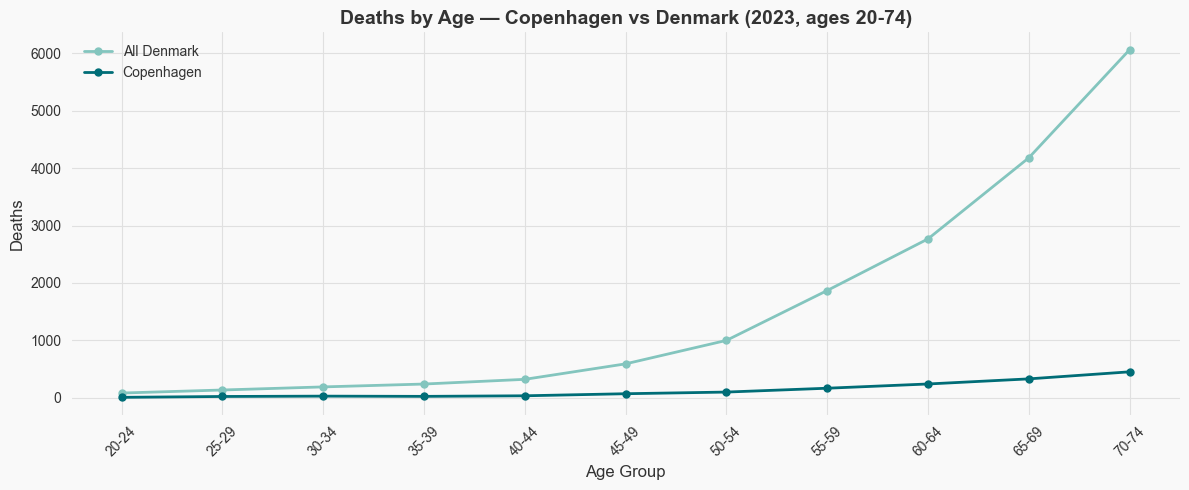


Copenhagen mortality rate (20-74, 2023): 278.7 per 100,000
HEAT default for Denmark: 500 per 100,000
Copenhagen deaths 20-74: 1,438
Copenhagen population 20-74: 515,913


In [45]:
# Compare Copenhagen vs All Denmark by age, most recent complete year
latest_fod_year = 2023  # Most recent complete year

# No "Total" gender in FOD207 — sum Men + Women
mask_fod = (
    (df_fod207["year"] == latest_fod_year)
    & (df_fod207["age"] != "Age, total")
    & (df_fod207["area"].isin(["All Denmark", "Copenhagen"]))
)
df_fod_compare = df_fod207[mask_fod].copy()


# Parse age for sorting
def parse_fod_age(age_str):
    try:
        return int(age_str.replace(" years", "").replace(" year", ""))
    except ValueError:
        return -1


df_fod_compare["age_num"] = df_fod_compare["age"].apply(parse_fod_age)
df_fod_compare = df_fod_compare[df_fod_compare["age_num"] >= 0]

# Sum across genders (Men + Women) per area and age
df_fod_compare = (
    df_fod_compare.groupby(["area", "age_num"])["deaths"].sum().reset_index()
)

# Filter to 20-74 range (HEAT walking range)
df_fod_heat = df_fod_compare[
    (df_fod_compare["age_num"] >= 20) & (df_fod_compare["age_num"] <= 74)
].copy()

# Group into 5-year bins for readability
df_fod_heat["age_bin"] = (df_fod_heat["age_num"] // 5) * 5
df_fod_binned = df_fod_heat.groupby(["area", "age_bin"])["deaths"].sum().reset_index()
df_fod_binned["age_label"] = df_fod_binned["age_bin"].apply(lambda x: f"{x}-{x + 4}")

fig, ax = plt.subplots(figsize=(12, 5))
for area, group in df_fod_binned.groupby("area"):
    color = (
        style.PALETTE["brand"] if area == "Copenhagen" else style.PALETTE["brand_light"]
    )
    group = group.sort_values("age_bin")
    ax.plot(
        group["age_label"],
        group["deaths"],
        marker="o",
        markersize=5,
        label=area,
        color=color,
    )

ax.set_xlabel("Age Group")
ax.set_ylabel("Deaths")
ax.set_title(f"Deaths by Age — Copenhagen vs Denmark ({latest_fod_year}, ages 20-74)")
ax.legend()
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

# Summary stats
mort = heat_inputs["mortality"]
print(
    f"\nCopenhagen mortality rate (20-74, {mort['year']}): {mort['rate_per_100k']:.1f} per 100,000"
)
print(f"HEAT default for Denmark: {mort['heat_default_denmark']} per 100,000")
print(f"Copenhagen deaths 20-74: {mort['deaths_20_74']:,}")
print(f"Copenhagen population 20-74: {mort['denominator_pop_20_74']:,}")

Fetching population data from StatBank FOLK1A...
  Copenhagen: 126 age rows, quarter 2026Q1, total pop 671,714
  All Denmark: 126 age rows, quarter 2026Q1, total pop 6,025,603


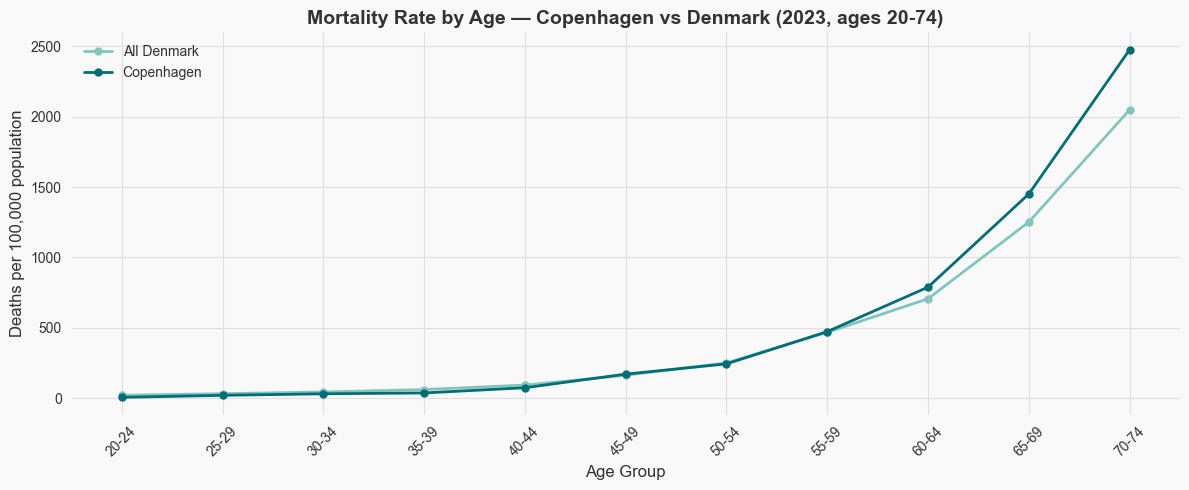


Overall mortality rate (20-74):
  Copenhagen: 278.7 per 100,000
  All Denmark: 424.3 per 100,000
  Copenhagen is 34% lower than the national average


In [ ]:
# Normalised comparison: mortality rate per 100,000 by age group
# Fetch population by age for Copenhagen and All Denmark from StatBank FOLK1A

import csv
import requests
from io import StringIO

STATBANK_API_URL = "https://api.statbank.dk/v1/data"


def fetch_population_by_age(area_code, area_label):
    """Fetch population by single-year age from StatBank FOLK1A."""
    payload = {
        "table": "FOLK1A",
        "format": "CSV",
        "lang": "en",
        "variables": [
            {"code": "OMRÅDE", "values": [area_code]},
            {"code": "ALDER", "values": ["*"]},
            {"code": "KØN", "values": ["TOT"]},
            {"code": "Tid", "values": ["*"]},
        ],
    }
    response = requests.post(STATBANK_API_URL, json=payload, timeout=120)
    response.raise_for_status()

    reader = csv.DictReader(StringIO(response.text), delimiter=";")
    rows = list(reader)

    # Use most recent quarter
    most_recent = sorted({r["TID"] for r in rows})[-1]

    records = []
    for row in rows:
        if row["TID"] != most_recent:
            continue
        age_str = row["ALDER"]
        if age_str == "Age, total":
            continue
        try:
            age = int(age_str.replace(" years", "").replace(" year", ""))
        except ValueError:
            continue
        records.append({"age_num": age, "population": int(row["INDHOLD"] or 0)})

    df = pd.DataFrame(records)
    df["area"] = area_label
    print(
        f"  {area_label}: {len(df)} age rows, quarter {most_recent}, total pop {df['population'].sum():,}"
    )
    return df


print("Fetching population data from StatBank FOLK1A...")
pop_cph = fetch_population_by_age("101", "Copenhagen")
pop_dk = fetch_population_by_age("000", "All Denmark")
df_pop_both = pd.concat([pop_cph, pop_dk], ignore_index=True)

# Bin into same 5-year groups as deaths chart
df_pop_both = df_pop_both[
    (df_pop_both["age_num"] >= 20) & (df_pop_both["age_num"] <= 74)
].copy()
df_pop_both["age_bin"] = (df_pop_both["age_num"] // 5) * 5
df_pop_binned = (
    df_pop_both.groupby(["area", "age_bin"])["population"].sum().reset_index()
)

# Merge with deaths data and compute rate per 100,000
df_rate = df_fod_binned.merge(df_pop_binned, on=["area", "age_bin"])
df_rate["rate_per_100k"] = df_rate["deaths"] / df_rate["population"] * 100_000
df_rate["age_label"] = df_rate["age_bin"].apply(lambda x: f"{x}-{x + 4}")

fig, ax = plt.subplots(figsize=(12, 5))
for area, group in df_rate.groupby("area"):
    color = (
        style.PALETTE["brand"] if area == "Copenhagen" else style.PALETTE["brand_light"]
    )
    group = group.sort_values("age_bin")
    ax.plot(
        group["age_label"],
        group["rate_per_100k"],
        marker="o",
        markersize=5,
        label=area,
        color=color,
    )

ax.set_xlabel("Age Group")
ax.set_ylabel("Deaths per 100,000 population")
ax.set_title(
    f"Mortality Rate by Age — Copenhagen vs Denmark ({latest_fod_year}, ages 20-74)"
)
ax.legend()
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

# Print the gap
cph_total_rate = (
    df_rate[df_rate["area"] == "Copenhagen"]["deaths"].sum()
    / df_rate[df_rate["area"] == "Copenhagen"]["population"].sum()
    * 100_000
)
dk_total_rate = (
    df_rate[df_rate["area"] == "All Denmark"]["deaths"].sum()
    / df_rate[df_rate["area"] == "All Denmark"]["population"].sum()
    * 100_000
)
print(f"\nOverall mortality rate (20-74):")
print(f"  Copenhagen: {cph_total_rate:.1f} per 100,000")
print(f"  All Denmark: {dk_total_rate:.1f} per 100,000")
print(
    f"  Copenhagen is {(1 - cph_total_rate / dk_total_rate):.0%} lower than the national average"
)

## 5. Health Behaviours — Danskernes Sundhed Survey

Copenhagen-level survey data from the Danish National Health Profile. The survey covers physical activity, obesity, stress, self-rated health, long-term illness, sedentary leisure, and GP contact rates.

### 5.1 Physical Activity — The Central Metric

Percentage of adults **not meeting WHO minimum physical activity recommendation** (150 min/week moderate activity).

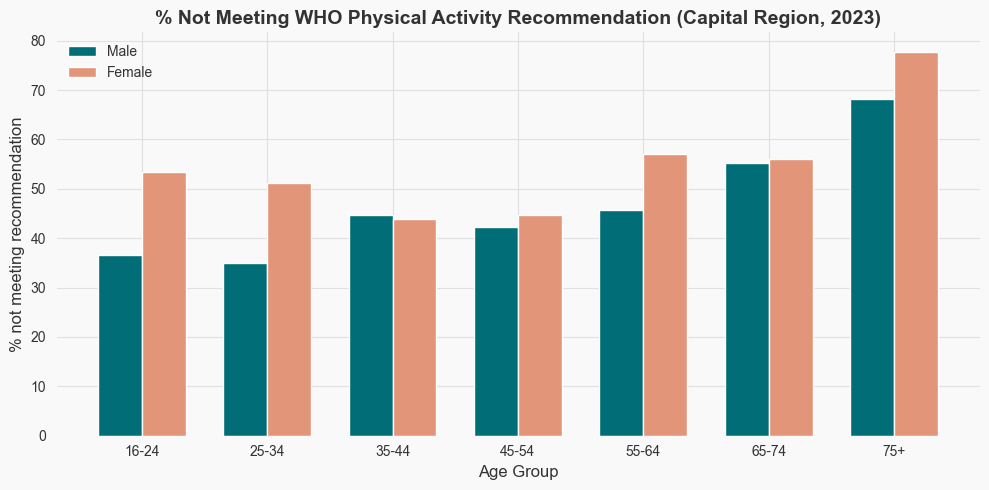

In [47]:
def plot_by_age_gender(indicator, title, ylabel="% of population", invert_better=True):
    """Plot a per-age indicator split by gender."""
    df = df_by_age[df_by_age["indicator"] == indicator].copy()
    if df.empty:
        print(f"No data for indicator: {indicator}")
        return

    # Use only the most recent year for this indicator
    latest = df["year"].max()
    df = df[df["year"] == latest]

    # Sort age groups
    age_order = ["16-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75+"]
    df["age_group"] = pd.Categorical(
        df["age_group"], categories=age_order, ordered=True
    )
    df = df.sort_values("age_group")

    fig, ax = plt.subplots(figsize=(10, 5))

    x = np.arange(len(age_order))
    width = 0.35

    males = df[df["gender"] == "Male"].set_index("age_group").reindex(age_order)
    females = df[df["gender"] == "Female"].set_index("age_group").reindex(age_order)

    ax.bar(
        x - width / 2,
        males["value_pct"],
        width,
        label="Male",
        color=style.PALETTE["brand"],
    )
    ax.bar(
        x + width / 2,
        females["value_pct"],
        width,
        label="Female",
        color=style.PALETTE["accent_warm"],
    )

    ax.set_xlabel("Age Group")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title} (Capital Region, {latest})")
    ax.set_xticks(x)
    ax.set_xticklabels(age_order)
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()


plot_by_age_gender(
    "physical_activity",
    "% Not Meeting WHO Physical Activity Recommendation",
    ylabel="% not meeting recommendation",
)

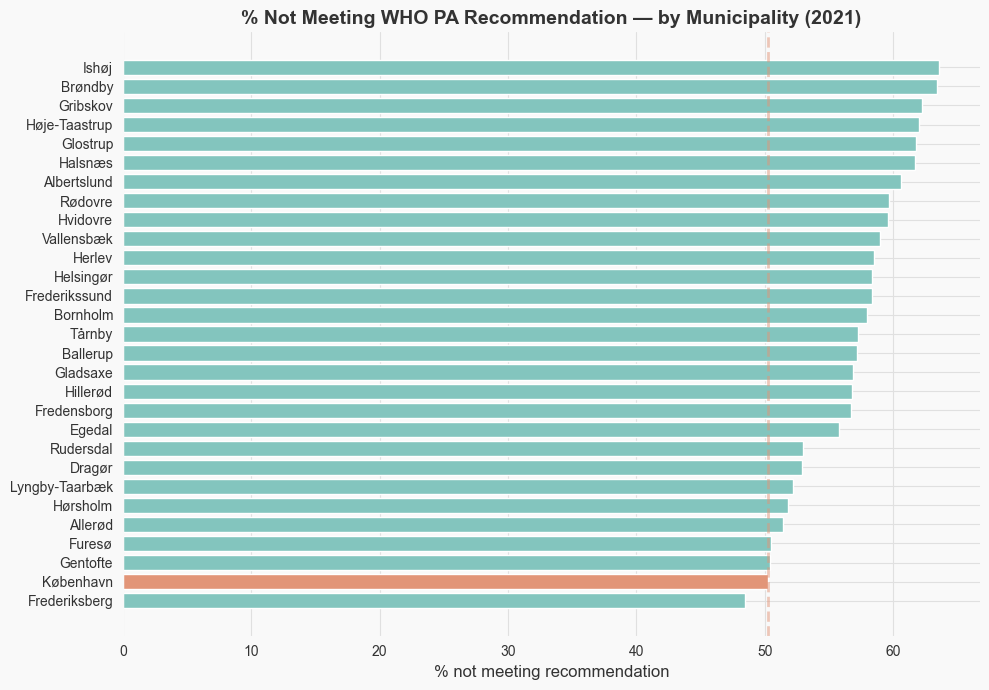

In [48]:
# Per-kommune: Copenhagen among Capital Region municipalities
def plot_by_municipality(indicator, title, ylabel="%", highlight="København"):
    """Plot per-municipality comparison with Copenhagen highlighted."""
    df = df_by_muni[df_by_muni["indicator"] == indicator].copy()
    if df.empty:
        print(f"No data for indicator: {indicator}")
        return

    df = df.sort_values("value_pct", ascending=True)

    colors = [
        style.PALETTE["accent_warm"] if m == highlight else style.PALETTE["brand_light"]
        for m in df["municipality"]
    ]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(df["municipality"], df["value_pct"], color=colors)
    ax.set_xlabel(ylabel)
    ax.set_title(f"{title} (2021)")

    # Highlight Copenhagen value
    cph_val = df[df["municipality"] == highlight]["value_pct"].values
    if len(cph_val) > 0:
        ax.axvline(
            cph_val[0], color=style.PALETTE["accent_warm"], linestyle="--", alpha=0.5
        )

    sns.despine()
    plt.tight_layout()
    plt.show()


plot_by_municipality(
    "physical_activity",
    "% Not Meeting WHO PA Recommendation — by Municipality",
    ylabel="% not meeting recommendation",
)

### 5.2 Obesity

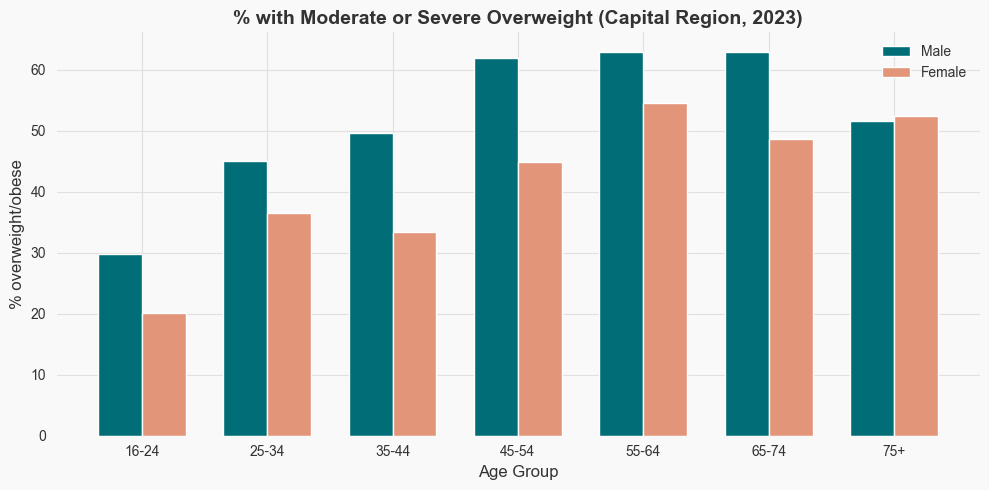

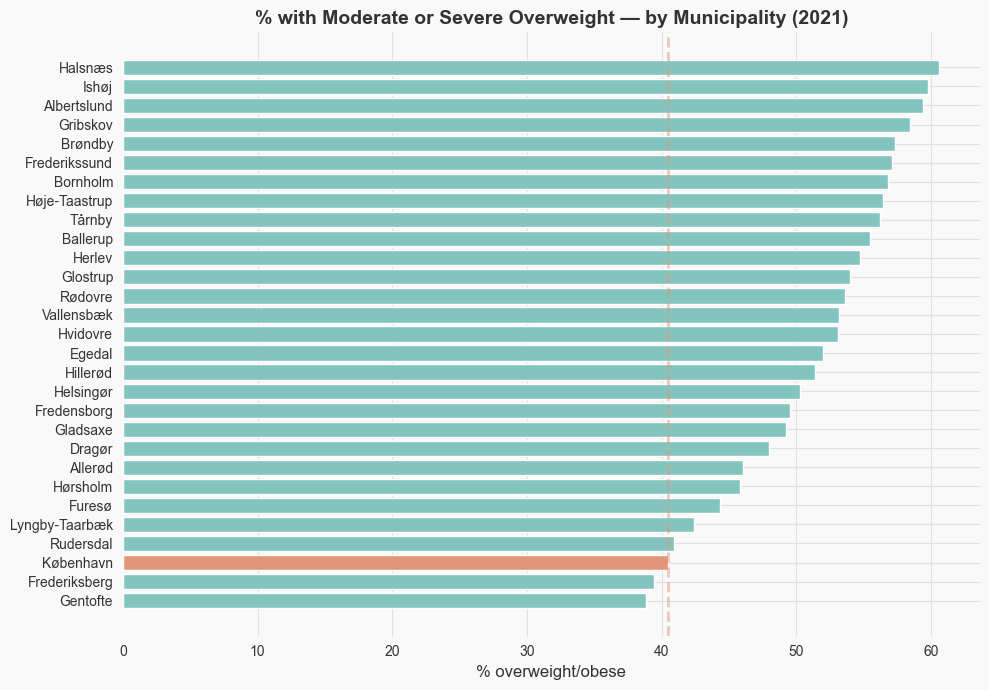

In [49]:
plot_by_age_gender(
    "obesity",
    "% with Moderate or Severe Overweight",
    ylabel="% overweight/obese",
)

plot_by_municipality(
    "obesity",
    "% with Moderate or Severe Overweight — by Municipality",
    ylabel="% overweight/obese",
)

### 5.3 Stress

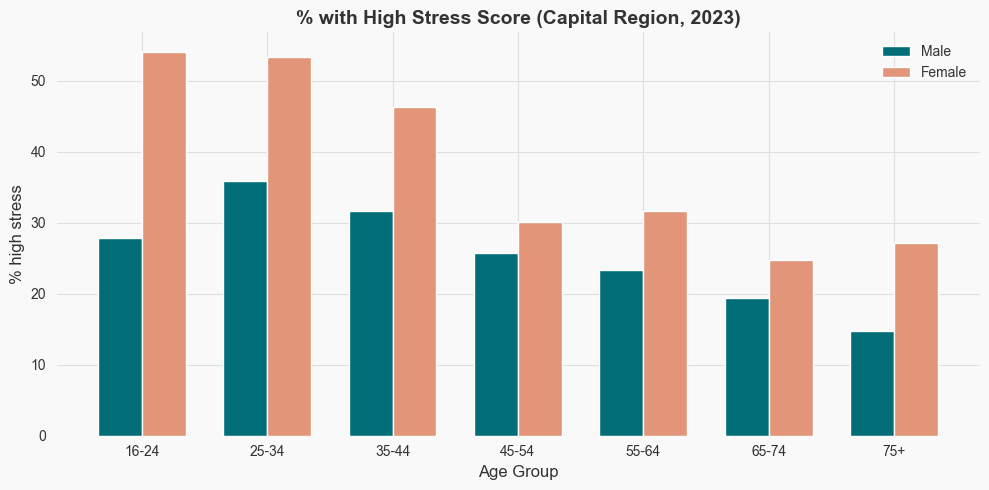

In [50]:
plot_by_age_gender(
    "stress",
    "% with High Stress Score",
    ylabel="% high stress",
)

### 5.4 Self-Rated Health

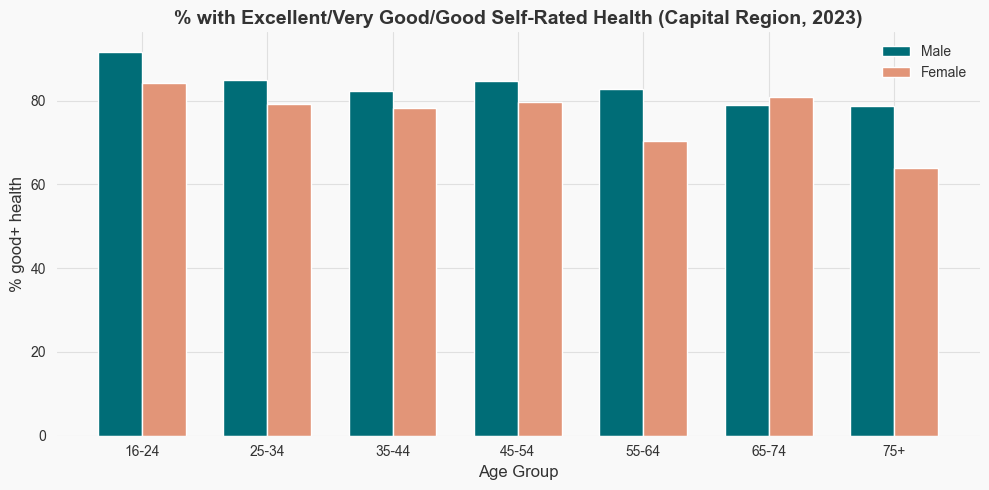

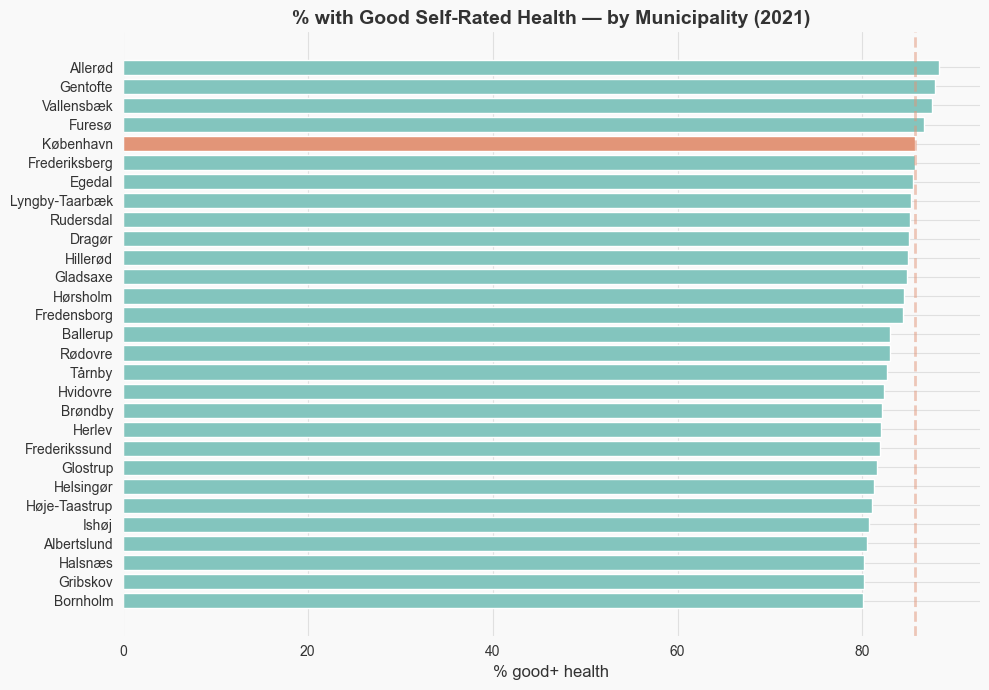

In [51]:
plot_by_age_gender(
    "self_rated_health",
    "% with Excellent/Very Good/Good Self-Rated Health",
    ylabel="% good+ health",
)

plot_by_municipality(
    "self_rated_health",
    "% with Good Self-Rated Health — by Municipality",
    ylabel="% good+ health",
)

### 5.5 Long-Term Illness

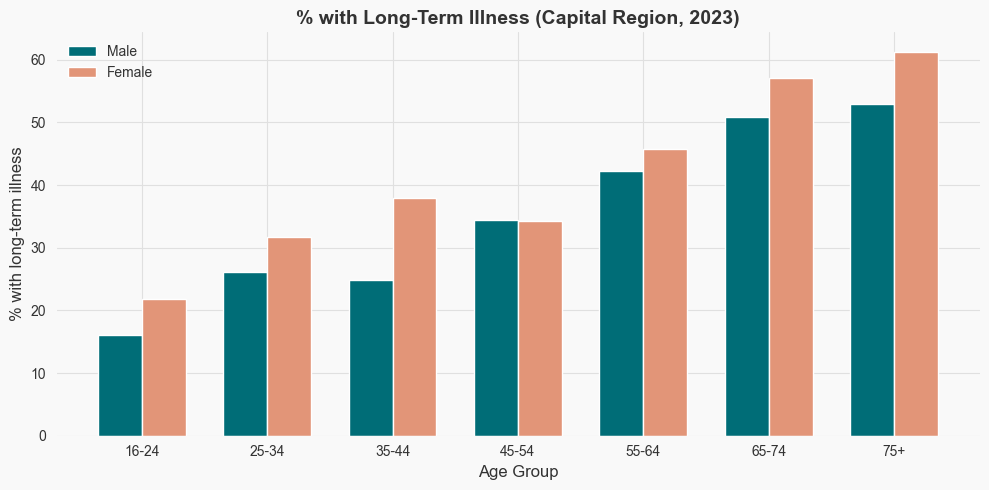

In [52]:
plot_by_age_gender(
    "longterm_illness",
    "% with Long-Term Illness",
    ylabel="% with long-term illness",
)

### 5.6 Sedentary Leisure — Time Series (2010, 2013, 2021)

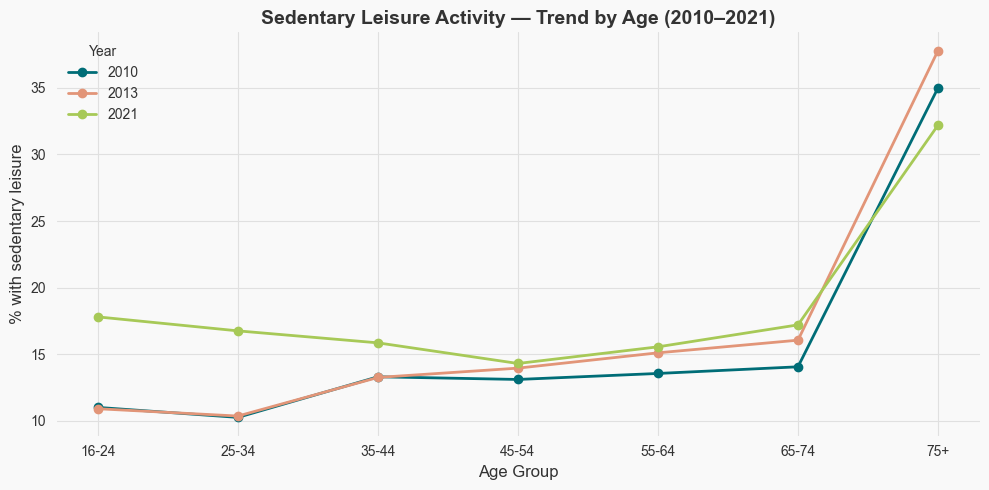

In [53]:
# Sedentary leisure has data for 3 years — show time trend
df_sed = df_by_age[df_by_age["indicator"] == "sedentary_leisure"].copy()

age_order = ["16-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75+"]
df_sed["age_group"] = pd.Categorical(
    df_sed["age_group"], categories=age_order, ordered=True
)

# Average across genders for cleaner trend view
df_sed_avg = df_sed.groupby(["year", "age_group"])["value_pct"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for year, group in df_sed_avg.groupby("year"):
    group = group.sort_values("age_group")
    ax.plot(
        group["age_group"].astype(str), group["value_pct"], marker="o", label=str(year)
    )

ax.set_xlabel("Age Group")
ax.set_ylabel("% with sedentary leisure")
ax.set_title("Sedentary Leisure Activity — Trend by Age (2010–2021)")
ax.legend(title="Year")
sns.despine()
plt.tight_layout()
plt.show()

### 5.7 GP Contact

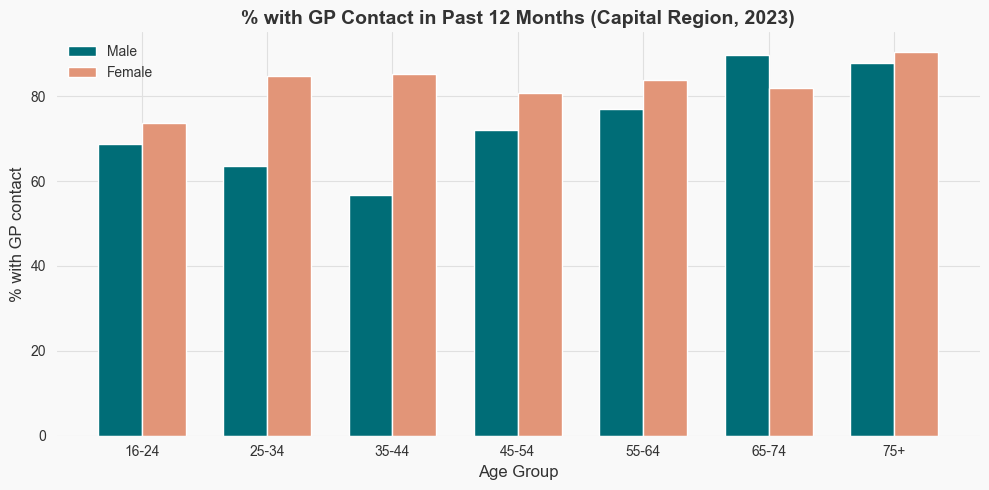

In [54]:
plot_by_age_gender(
    "gp_contact",
    "% with GP Contact in Past 12 Months",
    ylabel="% with GP contact",
)

### 5.8 Copenhagen Health Summary

Copenhagen's position across all indicators compared to the Capital Region municipalities.

In [55]:
# Summary table: Copenhagen vs average across all municipalities
summary_rows = []
for indicator in df_by_muni["indicator"].unique():
    df_ind = df_by_muni[df_by_muni["indicator"] == indicator]
    cph = df_ind[df_ind["municipality"] == "København"]
    avg = df_ind["value_pct"].mean()

    if len(cph) > 0:
        summary_rows.append(
            {
                "Indicator": indicator.replace("_", " ").title(),
                "Copenhagen (%)": f"{cph['value_pct'].values[0]:.1f}",
                "Region Average (%)": f"{avg:.1f}",
                "Odds Ratio (OR)": f"{cph['odds_ratio'].values[0]:.2f}",
            }
        )

df_summary = pd.DataFrame(summary_rows)
print("Copenhagen Health Indicators vs Capital Region Average (2021)")
print("OR < 1.0 = Copenhagen better than national average")
print("OR > 1.0 = Copenhagen worse than national average")
print()
display(df_summary)

Copenhagen Health Indicators vs Capital Region Average (2021)
OR < 1.0 = Copenhagen better than national average
OR > 1.0 = Copenhagen worse than national average



,Indicator,Copenhagen (%),Region Average (%),Odds Ratio (OR)
0,Physical Activity,50.3,56.9,0.74
1,Obesity,40.5,51.2,0.61
2,Stress,33.4,28.4,1.12
3,Self Rated Health,85.7,83.6,1.03
4,Longterm Illness,28.5,35.0,0.84
5,Gp Contact,71.1,73.4,1.01


## 6. WHO HEAT Results

Economic value of current walking and cycling levels in Nørrebro, calculated using the WHO HEAT web tool (v5.3). The assessment covers 4 pathways: physical activity benefits, air pollution exposure, crash risk, and carbon emissions savings.

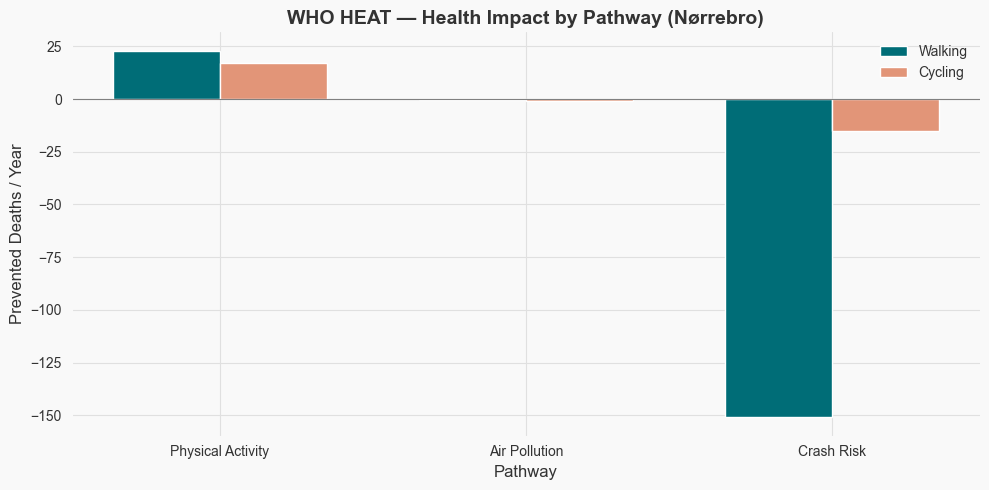


Key HEAT Results (annual):
  Walking PA benefit: +23 prevented deaths/year
  Cycling PA benefit: +17 prevented deaths/year
  Combined PA benefit: +40 prevented deaths/year
  Walking crash risk: -151 deaths/year
  Cycling crash risk: -15 deaths/year


In [56]:
# Parse HEAT results — focus on by-mode-by-pathway rows for walking and cycling
if not df_heat_results.empty:
    df_heat_bmp = df_heat_results[
        (df_heat_results["aggregationlevel"] == "bymodebypathway")
        & (df_heat_results["activemode"].isin(["walk", "bike"]))
    ].copy()

    # Clean up labels
    mode_labels = {"walk": "Walking", "bike": "Cycling"}
    pathway_labels = {
        "pa": "Physical Activity",
        "ap": "Air Pollution",
        "crash": "Crash Risk",
        "carbon": "Carbon",
    }

    df_heat_bmp["Mode"] = df_heat_bmp["activemode"].map(mode_labels)
    df_heat_bmp["Pathway"] = df_heat_bmp["pathway"].map(pathway_labels)

    # Deaths prevented per year (impactperyearave)
    df_deaths = df_heat_bmp[df_heat_bmp["pathway"] != "carbon"].copy()
    df_deaths["deaths_per_year"] = pd.to_numeric(
        df_deaths["impactperyearave"], errors="coerce"
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    # Group by pathway and mode
    pathways = ["Physical Activity", "Air Pollution", "Crash Risk"]
    x = np.arange(len(pathways))
    width = 0.35

    walk_vals = []
    bike_vals = []
    for pw in pathways:
        w = df_deaths[(df_deaths["Pathway"] == pw) & (df_deaths["Mode"] == "Walking")][
            "deaths_per_year"
        ]
        b = df_deaths[(df_deaths["Pathway"] == pw) & (df_deaths["Mode"] == "Cycling")][
            "deaths_per_year"
        ]
        walk_vals.append(w.values[0] if len(w) > 0 else 0)
        bike_vals.append(b.values[0] if len(b) > 0 else 0)

    bars1 = ax.bar(
        x - width / 2, walk_vals, width, label="Walking", color=style.PALETTE["brand"]
    )
    bars2 = ax.bar(
        x + width / 2,
        bike_vals,
        width,
        label="Cycling",
        color=style.PALETTE["accent_warm"],
    )

    ax.set_xlabel("Pathway")
    ax.set_ylabel("Prevented Deaths / Year")
    ax.set_title("WHO HEAT — Health Impact by Pathway (Nørrebro)")
    ax.set_xticks(x)
    ax.set_xticklabels(pathways)
    ax.axhline(y=0, color="grey", linewidth=0.8)
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

    # Print key numbers
    print("\nKey HEAT Results (annual):")
    print(f"  Walking PA benefit: {walk_vals[0]:+.0f} prevented deaths/year")
    print(f"  Cycling PA benefit: {bike_vals[0]:+.0f} prevented deaths/year")
    print(
        f"  Combined PA benefit: {walk_vals[0] + bike_vals[0]:+.0f} prevented deaths/year"
    )
    print(f"  Walking crash risk: {walk_vals[2]:+.0f} deaths/year")
    print(f"  Cycling crash risk: {bike_vals[2]:+.0f} deaths/year")
else:
    print("No HEAT results file found.")

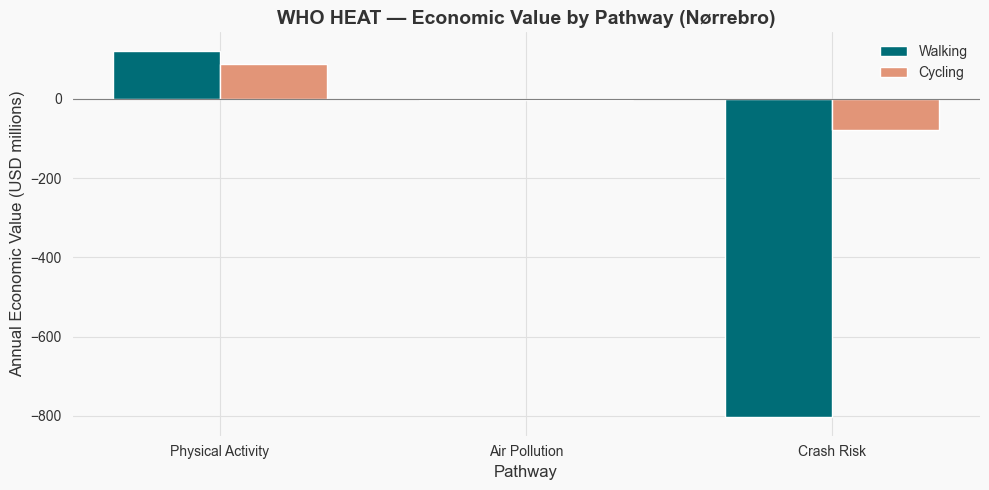


PA economic value: Walking $122M + Cycling $88M = $210M/year


In [57]:
# Economic valuation
if not df_heat_results.empty:
    df_econ = df_heat_bmp[df_heat_bmp["pathway"] != "carbon"].copy()
    df_econ["money_per_year_m"] = (
        pd.to_numeric(df_econ["moneyperyear"], errors="coerce") / 1_000_000
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    walk_money = []
    bike_money = []
    for pw in pathways:
        w = df_econ[(df_econ["Pathway"] == pw) & (df_econ["Mode"] == "Walking")][
            "money_per_year_m"
        ]
        b = df_econ[(df_econ["Pathway"] == pw) & (df_econ["Mode"] == "Cycling")][
            "money_per_year_m"
        ]
        walk_money.append(w.values[0] if len(w) > 0 else 0)
        bike_money.append(b.values[0] if len(b) > 0 else 0)

    bars1 = ax.bar(
        x - width / 2, walk_money, width, label="Walking", color=style.PALETTE["brand"]
    )
    bars2 = ax.bar(
        x + width / 2,
        bike_money,
        width,
        label="Cycling",
        color=style.PALETTE["accent_warm"],
    )

    ax.set_xlabel("Pathway")
    ax.set_ylabel("Annual Economic Value (USD millions)")
    ax.set_title("WHO HEAT — Economic Value by Pathway (Nørrebro)")
    ax.set_xticks(x)
    ax.set_xticklabels(pathways)
    ax.axhline(y=0, color="grey", linewidth=0.8)
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

    print(
        f"\nPA economic value: Walking ${walk_money[0]:.0f}M + Cycling ${bike_money[0]:.0f}M = ${walk_money[0] + bike_money[0]:.0f}M/year"
    )

In [58]:
# HEAT input parameters summary
print("HEAT Input Parameters (Nørrebro Assessment)")
print("=" * 50)
pop = heat_inputs["population"]
print(f"Population total:           {pop['total']:>10,}")
print(f"Walking eligible (20-74):   {pop['aged_20_74_walking']:>10,}")
print(f"Cycling eligible (20-64):   {pop['aged_20_64_cycling']:>10,}")
print()
mort = heat_inputs["mortality"]
print(f"Mortality rate (20-74):     {mort['rate_per_100k']:>10.1f} per 100k")
print(f"HEAT default (Denmark):     {mort['heat_default_denmark']:>10} per 100k")
print()
ms = heat_inputs["modal_share"]
print(f"Modal share walking:        {ms['walking']:>10.0%}")
print(f"Modal share cycling:        {ms['cycling']:>10.0%}")
print()
ap = heat_inputs["air_pollution"]
print(f"PM2.5 annual mean:          {ap['pm25_annual_mean_ugm3']:>10.1f} µg/m³")
rc = heat_inputs["road_crashes"]
print(
    f"Cycling fatality rate:      {rc['cycling_fatality_per_billion_km']:>10.1f} per billion km"
)

HEAT Input Parameters (Nørrebro Assessment)
Population total:               79,753
Walking eligible (20-74):       63,529
Cycling eligible (20-64):       59,605

Mortality rate (20-74):          278.7 per 100k
HEAT default (Denmark):            500 per 100k

Modal share walking:               21%
Modal share cycling:               28%

PM2.5 annual mean:                 9.8 µg/m³
Cycling fatality rate:            15.9 per billion km


## 7. Narrative Summary

### The Problem

Approximately **50% of Copenhagen adults** do not meet the WHO minimum recommendation for physical activity (150 minutes of moderate activity per week). Physical inactivity rises steeply with age — from ~37% among men aged 16-24 to **68-78% among those 75+**. Women consistently report higher inactivity rates than men across most age groups.

The health consequences are clear in national mortality data: **heart disease, metabolic disorders (including diabetes), and respiratory diseases** remain among the leading causes of death in Denmark. All three are strongly linked to physical inactivity and can be mitigated through regular moderate exercise — including walking and cycling for transport.

### The Opportunity

Nørrebro's **79,753 residents** already benefit from Copenhagen's strong active transport culture, with a **21% walking and 28% cycling modal share**. The WHO HEAT model estimates that current walking and cycling levels prevent approximately **40 premature deaths per year** in Nørrebro, with a combined economic value of **~$210 million annually** from physical activity benefits alone.

Copenhagen's calculated mortality rate (278.7 per 100,000 for ages 20-74) is substantially lower than the national HEAT default (500), likely reflecting the city's younger demographic profile and existing active transport infrastructure.

### The Gap

Physical activity drops off sharply after age 55, with the steepest decline among women. **Long-term illness affects over 50% of those aged 75+**, and sedentary leisure time increases with age. Yet these are precisely the populations that benefit most from even modest increases in daily walking.

Infrastructure that makes walking and cycling **safe, comfortable, and accessible for older adults** — smooth surfaces, frequent crossings, benches, shade, and protection from traffic — could close this activity gap and extend the health benefits of active transport to the populations that need it most.

### The Design Imperative

The quality of the walking and cycling environment — surface quality, crossing safety, green corridors, separation from traffic — directly affects **who** uses active transport and **for how long**. This is where urban design becomes preventive healthcare.

The data shows that the infrastructure-health connection is not abstract: it can be quantified in prevented deaths and economic value. Every design decision about a cycle path, a pedestrian crossing, or a green corridor is also a decision about public health outcomes.

**Note on crash risk**: The HEAT model applies conservative international crash fatality defaults, which produce large negative values. Denmark's actual cycling fatality rate is among the lowest in the world. The physical activity benefits are the dominant and most reliable finding from this assessment.